# 03 — Investigação: por que os pedidos atrasam ou não chegam

Os notebooks 01 e 02 mostram **o que** acontece (taxa de atraso, impacto na nota). Este notebook investiga **por que**, respondendo cinco perguntas:

1. Por que alguns pedidos não foram entregues?
2. Quanto dado incompleto ou inconsistente existe na base?
3. É possível saber quantos clientes não foram localizados?
4. Em qual etapa do processo o atraso acontece?
5. O que a base mostra sobre falhas de pagamento?

Para cada pergunta, o notebook deixa claro o que os dados **respondem** e o que **não respondem**.

In [1]:
from pathlib import Path
import unicodedata

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.float_format", "{:,.2f}".format)

RAW = Path("../data/raw")
IMG = Path("../imagens")

datas = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

pedidos = pd.read_csv(RAW / "olist_orders_dataset.csv", parse_dates=datas)
clientes = pd.read_csv(RAW / "olist_customers_dataset.csv")
vendedores = pd.read_csv(RAW / "olist_sellers_dataset.csv")
itens = pd.read_csv(RAW / "olist_order_items_dataset.csv", parse_dates=["shipping_limit_date"])
produtos = pd.read_csv(RAW / "olist_products_dataset.csv")
pagamentos = pd.read_csv(RAW / "olist_order_payments_dataset.csv")
avaliacoes = pd.read_csv(RAW / "olist_order_reviews_dataset.csv")
geo = pd.read_csv(RAW / "olist_geolocation_dataset.csv", usecols=["geolocation_zip_code_prefix"])

# Critério de atraso usado em todo o projeto: compara só a data, sem a hora
pedidos["atrasado"] = (
    pedidos["order_delivered_customer_date"].dt.normalize()
    > pedidos["order_estimated_delivery_date"].dt.normalize()
)

## 1. Por que alguns pedidos não foram entregues?

A base não tem um campo de "motivo". O status do pedido e os comentários das avaliações são as melhores pistas disponíveis.

In [2]:
nao_entregues = pedidos[pedidos["order_status"] != "delivered"]

status = (
    nao_entregues["order_status"]
    .value_counts()
    .rename_axis("status")
    .reset_index(name="pedidos")
)
status["percentual"] = status["pedidos"] / status["pedidos"].sum() * 100

print(f"Pedidos não entregues: {len(nao_entregues):,}")
status

Pedidos não entregues: 2,963


,status,pedidos,percentual
0,shipped,1107,37.36
1,canceled,625,21.09
2,unavailable,609,20.55
3,invoiced,314,10.60
4,processing,301,10.16
5,created,5,0.17
6,approved,2,0.07


In [3]:
# Pedidos enviados à transportadora que nunca tiveram entrega confirmada
enviados = pedidos[pedidos["order_status"] == "shipped"]
fim_da_base = pedidos["order_purchase_timestamp"].max()

vencidos = (enviados["order_estimated_delivery_date"] < fim_da_base).sum()
print(f"Pedidos 'shipped': {len(enviados):,}")
print(f"Com prazo estimado já vencido no fim da base ({fim_da_base:%d/%m/%Y}): {vencidos:,}")

Pedidos 'shipped': 1,107
Com prazo estimado já vencido no fim da base (17/10/2018): 1,107


Os comentários das avaliações foram classificados por palavras-chave. A contagem é **aproximada**: um comentário pode citar mais de um tema, e frases escritas de outro jeito não são capturadas.

In [4]:
def normalizar(texto):
    texto = unicodedata.normalize("NFKD", str(texto).lower())
    return texto.encode("ascii", "ignore").decode()

avaliacoes["texto"] = (
    avaliacoes["review_comment_title"].fillna("") + " "
    + avaliacoes["review_comment_message"].fillna("")
).map(normalizar)

temas = {
    "Não recebi / não chegou": r"nao (?:recebi|chegou|foi entregue|entregaram)",
    "Cancelamento / estorno": r"cancel|estorno|reembolso|devolu",
    "Correios / transportadora": r"correio|transportadora|rastre",
    "Produto errado ou incompleto": r"errado|diferente|faltando|incompleto",
    "Endereço / destinatário": r"endereco|destinatario|nao localiz|ausente",
}

def resumo_comentarios(ids):
    base = avaliacoes[avaliacoes["order_id"].isin(ids)]
    com_texto = base[base["texto"].str.strip() != ""]
    linhas = [{"tema": t, "comentarios": com_texto["texto"].str.contains(p).sum()} for t, p in temas.items()]
    print(f"Avaliações: {len(base):,} | nota média: {base['review_score'].mean():.2f} | com comentário: {len(com_texto):,}")
    return pd.DataFrame(linhas)

resumo_comentarios(nao_entregues["order_id"])

Avaliações: 2,863 | nota média: 1.75 | com comentário: 1,903


,tema,comentarios
0,Não recebi / não chegou,699
1,Cancelamento / estorno,325
2,Correios / transportadora,110
3,Produto errado ou incompleto,39
4,Endereço / destinatário,2


## 2. Quanto dado incompleto ou inconsistente existe?

In [5]:
incompletos = pd.DataFrame([
    ("Pedidos sem data de entrega ao cliente", pedidos["order_delivered_customer_date"].isna().sum()),
    ("Pedidos sem data de postagem", pedidos["order_delivered_carrier_date"].isna().sum()),
    ("Pedidos sem data de aprovação do pagamento", pedidos["order_approved_at"].isna().sum()),
    ("Pedidos sem nenhum item", (~pedidos["order_id"].isin(itens["order_id"])).sum()),
    ("Pedidos sem registro de pagamento", (~pedidos["order_id"].isin(pagamentos["order_id"])).sum()),
    ("Produtos sem categoria", produtos["product_category_name"].isna().sum()),
    ("Avaliações sem comentário", avaliacoes["review_comment_message"].isna().sum()),
], columns=["problema", "quantidade"])

inconsistentes = pd.DataFrame([
    ("Postado antes da compra",
     (pedidos["order_delivered_carrier_date"] < pedidos["order_purchase_timestamp"]).sum()),
    ("Entregue antes de ser postado",
     (pedidos["order_delivered_customer_date"] < pedidos["order_delivered_carrier_date"]).sum()),
    ("Status 'delivered' sem data de entrega",
     ((pedidos["order_status"] == "delivered") & pedidos["order_delivered_customer_date"].isna()).sum()),
    ("Status diferente de 'delivered' com data de entrega",
     ((pedidos["order_status"] != "delivered") & pedidos["order_delivered_customer_date"].notna()).sum()),
], columns=["inconsistência", "quantidade"])

display(incompletos)
inconsistentes

,problema,quantidade
0,Pedidos sem data de entrega ao cliente,2965
1,Pedidos sem data de postagem,1783
2,Pedidos sem data de aprovação do pagamento,160
3,Pedidos sem nenhum item,775
4,Pedidos sem registro de pagamento,1
5,Produtos sem categoria,610
6,Avaliações sem comentário,58247


,inconsistência,quantidade
0,Postado antes da compra,166
1,Entregue antes de ser postado,23
2,Status 'delivered' sem data de entrega,8
3,Status diferente de 'delivered' com data de en...,6


## 3. É possível saber quantos clientes não foram localizados?

**Não.** A base não registra tentativas de entrega nem ocorrências como "destinatário ausente" ou "endereço não localizado". Existem apenas pistas indiretas, que **não** medem esse problema:

In [6]:
ceps_conhecidos = set(geo["geolocation_zip_code_prefix"])
sem_cep = clientes[~clientes["customer_zip_code_prefix"].isin(ceps_conhecidos)]

problema = pedidos.loc[(pedidos["order_status"] != "delivered") | pedidos["atrasado"], "order_id"]
coment_problema = avaliacoes[avaliacoes["order_id"].isin(problema) & (avaliacoes["texto"].str.strip() != "")]
cita_endereco = coment_problema["texto"].str.contains(temas["Endereço / destinatário"]).sum()

print(f"Clientes com CEP ausente da tabela de geolocalização: {len(sem_cep):,}")
print(f"Comentários de pedidos não entregues ou atrasados: {len(coment_problema):,}")
print(f"Desses, citam endereço ou destinatário: {cita_endereco:,}")

Clientes com CEP ausente da tabela de geolocalização: 278
Comentários de pedidos não entregues ou atrasados: 5,749
Desses, citam endereço ou destinatário: 5


## 4. Em qual etapa o atraso acontece?

Cada pedido passa por três etapas: **aprovação do pagamento** (compra → aprovação), **postagem pelo vendedor** (aprovação → entrega à transportadora) e **transporte** (transportadora → cliente). Comparando a duração de cada etapa entre pedidos no prazo e atrasados, dá para ver onde o tempo se perde.

São considerados apenas pedidos com as quatro datas preenchidas e sem durações negativas (datas inconsistentes).

In [7]:
etapas = pedidos.dropna(subset=[
    "order_approved_at", "order_delivered_carrier_date", "order_delivered_customer_date"
]).copy()

dias = lambda fim, inicio: (etapas[fim] - etapas[inicio]).dt.total_seconds() / 86400
etapas["Aprovação do pagamento"] = dias("order_approved_at", "order_purchase_timestamp")
etapas["Postagem pelo vendedor"] = dias("order_delivered_carrier_date", "order_approved_at")
etapas["Transporte até o cliente"] = dias("order_delivered_customer_date", "order_delivered_carrier_date")

colunas = ["Aprovação do pagamento", "Postagem pelo vendedor", "Transporte até o cliente"]
etapas = etapas[(etapas[colunas] >= 0).all(axis=1)]
etapas["grupo"] = etapas["atrasado"].map({False: "No prazo", True: "Atrasados"})

mediana_etapas = etapas.groupby("grupo")[colunas].median().T[["No prazo", "Atrasados"]]
print(f"Pedidos analisados: {len(etapas):,} (atrasados: {etapas['atrasado'].sum():,})")
mediana_etapas

Pedidos analisados: 95,088 (atrasados: 6,510)


grupo,No prazo,Atrasados
Aprovação do pagamento,0.01,0.02
Postagem pelo vendedor,1.79,3.07
Transporte até o cliente,6.96,26.20


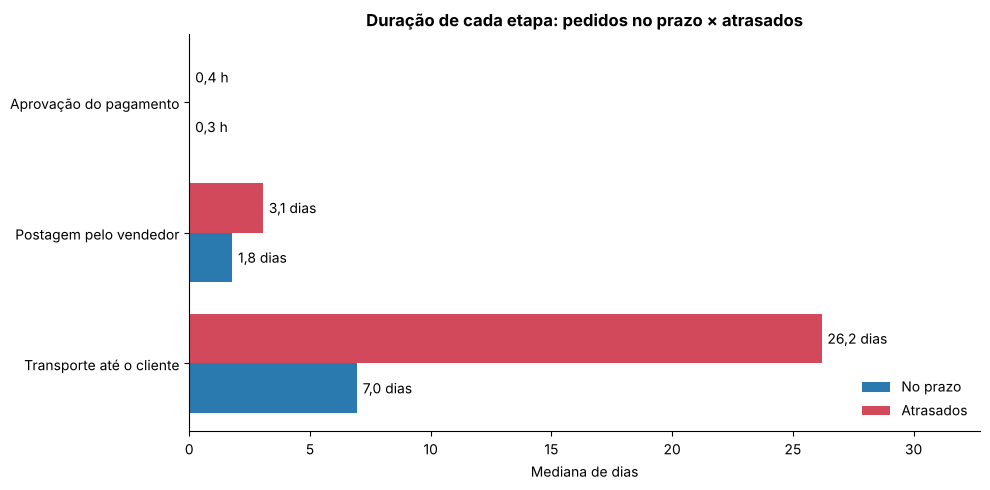

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
posicoes = range(len(colunas))
largura = 0.38

b1 = ax.barh([p + largura / 2 for p in posicoes], mediana_etapas["No prazo"], largura, color="#2a7ab0", label="No prazo")
b2 = ax.barh([p - largura / 2 for p in posicoes], mediana_etapas["Atrasados"], largura, color="#d1495b", label="Atrasados")
def rotulo(v):
    # Menos de 1 dia aparece em horas, para não virar "0,0 dias"
    texto = f"{v * 24:.1f} h" if v < 1 else f"{v:.1f} dias"
    return texto.replace(".", ",")

ax.bar_label(b1, labels=[rotulo(v) for v in mediana_etapas["No prazo"]], padding=4)
ax.bar_label(b2, labels=[rotulo(v) for v in mediana_etapas["Atrasados"]], padding=4)

ax.set_yticks(list(posicoes))
ax.set_yticklabels(colunas)
ax.invert_yaxis()
ax.set_xlabel("Mediana de dias")
ax.set_title("Duração de cada etapa: pedidos no prazo × atrasados", fontweight="bold")
ax.set_xlim(0, mediana_etapas.values.max() * 1.25)
ax.legend(loc="lower right", frameon=False)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(IMG / "etapas_atraso.png", dpi=300, bbox_inches="tight")
plt.show()

### 4.1 O vendedor postou dentro do prazo combinado?

Cada item tem uma data limite para o vendedor entregar o produto à transportadora (`shipping_limit_date`).

In [9]:
limite = itens.groupby("order_id")["shipping_limit_date"].max()
etapas = etapas.join(limite, on="order_id")
etapas["vendedor_postou_atrasado"] = etapas["order_delivered_carrier_date"] > etapas["shipping_limit_date"]

postagem = (
    etapas.groupby("vendedor_postou_atrasado")["atrasado"]
    .agg(pedidos="count", taxa_de_atraso="mean")
    .rename(index={False: "Vendedor postou no prazo", True: "Vendedor postou atrasado"})
)
postagem["taxa_de_atraso"] *= 100

print(f"Atrasados em que o vendedor postou depois do limite: {etapas.loc[etapas['atrasado'], 'vendedor_postou_atrasado'].mean():.1%}")
print(f"No prazo em que o vendedor postou depois do limite: {etapas.loc[~etapas['atrasado'], 'vendedor_postou_atrasado'].mean():.1%}")
postagem

Atrasados em que o vendedor postou depois do limite: 27.9%
No prazo em que o vendedor postou depois do limite: 7.8%


,pedidos,taxa_de_atraso
vendedor_postou_atrasado,,
Vendedor postou no prazo,86398,5.44
Vendedor postou atrasado,8690,20.87


### 4.2 Distância: mesmo estado × outro estado

Considera o estado do primeiro vendedor do pedido.

In [10]:
estado_vendedor = itens.merge(vendedores, on="seller_id").groupby("order_id")["seller_state"].first()

entregues = pedidos[pedidos["order_delivered_customer_date"].notna()].copy()
entregues = entregues.join(estado_vendedor, on="order_id").merge(
    clientes[["customer_id", "customer_state"]], on="customer_id"
)
entregues["rota"] = (entregues["seller_state"] == entregues["customer_state"]).map(
    {True: "Mesmo estado", False: "Outro estado"}
)

distancia = entregues.groupby("rota")["atrasado"].agg(pedidos="count", taxa_de_atraso="mean")
distancia["taxa_de_atraso"] *= 100
distancia

,pedidos,taxa_de_atraso
rota,,
Mesmo estado,34703,4.50
Outro estado,61773,8.05


### 4.3 Sazonalidade: taxa de atraso por mês da compra

In [11]:
entregues["mes"] = entregues["order_purchase_timestamp"].dt.to_period("M")
mensal = (
    entregues.groupby("mes")["atrasado"]
    .agg(pedidos="count", taxa_de_atraso="mean")
    .loc["2017-01":"2018-08"]
)
mensal["taxa_de_atraso"] *= 100

print("Meses com maior taxa de atraso:")
display(mensal.sort_values("taxa_de_atraso", ascending=False).head(4))

prazo_prometido = (
    (entregues["order_estimated_delivery_date"] - entregues["order_purchase_timestamp"]).dt.days
    .groupby(entregues["atrasado"]).median()
)
print(f"Prazo prometido (mediana): no prazo {prazo_prometido[False]:.0f} dias | atrasados {prazo_prometido[True]:.0f} dias")

Meses com maior taxa de atraso:


,pedidos,taxa_de_atraso
mes,,
2018-03,7003,18.96
2018-02,6556,14.14
2017-11,7288,12.40
2017-12,5513,7.46


Prazo prometido (mediana): no prazo 23 dias | atrasados 22 dias


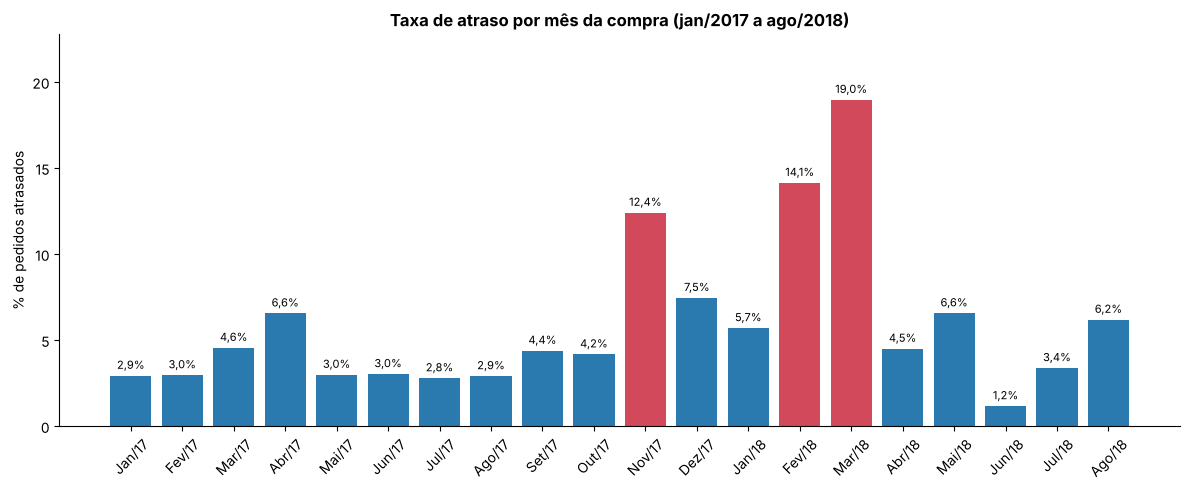

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))
meses_pt = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun", "Jul", "Ago", "Set", "Out", "Nov", "Dez"]
rotulos = [f"{meses_pt[p.month - 1]}/{p.strftime('%y')}" for p in mensal.index]
cores = ["#d1495b" if v >= 12 else "#2a7ab0" for v in mensal["taxa_de_atraso"]]
barras = ax.bar(rotulos, mensal["taxa_de_atraso"], color=cores)
ax.bar_label(barras, labels=[f"{v:.1f}%".replace(".", ",") for v in mensal["taxa_de_atraso"]], padding=3, fontsize=8)

ax.set_title("Taxa de atraso por mês da compra (jan/2017 a ago/2018)", fontweight="bold")
ax.set_ylabel("% de pedidos atrasados")
ax.set_ylim(0, mensal["taxa_de_atraso"].max() * 1.2)
ax.spines[["top", "right"]].set_visible(False)
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(IMG / "atraso_por_mes.png", dpi=300, bbox_inches="tight")
plt.show()

### 4.4 Comentários dos clientes com pedidos atrasados

In [13]:
resumo_comentarios(pedidos.loc[pedidos["atrasado"], "order_id"])

Avaliações: 6,410 | nota média: 2.27 | com comentário: 3,847


,tema,comentarios
0,Não recebi / não chegou,1573
1,Cancelamento / estorno,138
2,Correios / transportadora,407
3,Produto errado ou incompleto,58
4,Endereço / destinatário,3


## 5. O que a base mostra sobre falhas de pagamento?

A tabela de pagamentos tem apenas cinco colunas: pedido, sequência, forma de pagamento, parcelas e valor. **Não existe registro de tentativas recusadas nem do motivo da recusa** (sem limite, cartão bloqueado, antifraude). Uma compra recusada provavelmente nem chega a virar pedido nesta base. O que dá para medir:

In [14]:
print("Colunas da tabela de pagamentos:", pagamentos.columns.tolist())

formas = pagamentos.groupby("order_id")["payment_type"].agg(lambda s: " + ".join(sorted(set(s))))
pedidos_pag = pedidos.join(formas.rename("forma_pagamento"), on="order_id")

sem_aprovacao = pedidos_pag[pedidos_pag["order_approved_at"].isna()]
print(f"Pedidos sem aprovação do pagamento: {len(sem_aprovacao):,}")
display(sem_aprovacao["order_status"].value_counts().rename("pedidos").to_frame())
sem_aprovacao["forma_pagamento"].value_counts().rename("pedidos").to_frame()

Colunas da tabela de pagamentos: ['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']


Pedidos sem aprovação do pagamento: 160


,pedidos
order_status,
canceled,141
delivered,14
created,5


,pedidos
forma_pagamento,
voucher,71
credit_card,54
boleto,30
not_defined,3
credit_card + voucher,2


In [15]:
pedidos_pag["horas_ate_aprovacao"] = (
    pedidos_pag["order_approved_at"] - pedidos_pag["order_purchase_timestamp"]
).dt.total_seconds() / 3600
pedidos_pag["cancelado"] = pedidos_pag["order_status"].isin(["canceled", "unavailable"])

principais = ["credit_card", "boleto", "voucher", "debit_card"]
por_forma = (
    pedidos_pag[pedidos_pag["forma_pagamento"].isin(principais)]
    .groupby("forma_pagamento")
    .agg(
        pedidos=("order_id", "count"),
        horas_ate_aprovacao_mediana=("horas_ate_aprovacao", "median"),
        taxa_cancelamento=("cancelado", "mean"),
    )
)
por_forma["taxa_cancelamento"] *= 100
por_forma.sort_values("horas_ate_aprovacao_mediana")

,pedidos,horas_ate_aprovacao_mediana,taxa_cancelamento
forma_pagamento,,,
credit_card,74259,0.27,1.15
voucher,1621,0.31,5.31
debit_card,1527,0.85,0.85
boleto,19784,29.07,1.24


## 6. Conclusões

**O que a base responde**
- Quase 3 mil pedidos não foram entregues; o maior grupo (`shipped`) saiu para a transportadora e nunca teve entrega confirmada, o que indica extravio ou falta de baixa.
- O **transporte** é a etapa que mais explica o atraso: nos pedidos atrasados, ele leva cerca de 4 vezes mais tempo.
- Quando o **vendedor posta depois do prazo**, a chance de atraso quase quadruplica.
- Entregas para **outro estado** e compras em **meses de pico** (fev e mar/2018, nov/2017) atrasam mais.
- O prazo prometido é parecido para pedidos no prazo e atrasados: o problema está na execução, não na promessa.

**O que a base não responde**
- Motivo de não entrega e ocorrências no trajeto (extravio, destinatário ausente, endereço não localizado).
- Motivo de recusa de pagamento (sem limite, cartão bloqueado, antifraude).

Para responder essas perguntas numa empresa, seria preciso cruzar estes dados com os registros da transportadora (eventos de rastreamento) e do gateway de pagamento (códigos de recusa).